# Bangla TTS Fine-Tuning — VITS (facebook/mms-tts-ben)
Fine-tunes the pretrained MMS-TTS Bengali model on the IIT-Madras Comprehensive Bangla TTS dataset
to produce a more realistic, natural-sounding voice. Runs end-to-end on Kaggle T4 GPU (~4–6 hrs).


In [1]:
!pip install -q transformers==4.40.0 datasets accelerate librosa soundfile pesq matplotlib
!pip install -q torch torchaudio --index-url https://download.pytorch.org/whl/cu118


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 8.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 89.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 100.4 MB/s eta 0:00:0000:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.2.3 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0 which is incompatible.


In [2]:
import os, re, json, time, math, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import torchaudio
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
from IPython.display import Audio, display
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from transformers import VitsModel, AutoTokenizer
warnings.filterwarnings("ignore")

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

class Config:
    # ── Paths ──────────────────────────────────────────────────────────────────
    DATA_ROOT   = "/kaggle/input/datasets/mobassir/comprehensive-bangla-tts/iitm_bangla_tts/comprehensive_bangla_tts"
    MONO_DIR    = f"{DATA_ROOT}/female/mono"
    METADATA    = f"{MONO_DIR}/metadata_female.txt"
    WAV_DIR     = f"{MONO_DIR}/wav"          # actual wav folder (not wavs)
    OUTPUT_DIR  = "/kaggle/working/outputs"
    CKPT_DIR    = "/kaggle/working/checkpoints"
    BEST_CKPT   = f"{CKPT_DIR}/best_model.pt"

    # ── Audio ──────────────────────────────────────────────────────────────────
    SAMPLE_RATE = 16000
    MAX_WAV_LEN = 10.0       # seconds — skip very long utterances
    MIN_WAV_LEN = 0.5        # seconds — skip near-silent clips

    # ── Training ───────────────────────────────────────────────────────────────
    PRETRAINED  = "facebook/mms-tts-ben"
    BATCH_SIZE  = 4          # T4 fits 4 comfortably; lower to 2 if OOM
    GRAD_ACCUM  = 4          # effective batch = 16
    EPOCHS      = 2
    LR          = 2e-4
    WEIGHT_DECAY= 1e-2
    WARMUP_PCT  = 0.1
    VAL_SPLIT   = 0.05       # 5 % held-out validation
    MAX_SAMPLES = None       # set to e.g. 500 for a quick smoke-test; None = full dataset

    # ── Which layers to unfreeze ───────────────────────────────────────────────
    # We keep the text encoder frozen and only fine-tune the vocoder (flow + decoder)
    # This is far more stable for a domain-adaptation run.
    UNFREEZE_MODULES = ["flow", "decoder", "duration_predictor"]

    # ── Inference ─────────────────────────────────────────────────────────────
    SPEAKING_RATE   = 0.90   # slightly slower → clearer Bangla
    NUM_EVAL_SAMPLES= 5

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
os.makedirs(Config.OUTPUT_DIR, exist_ok=True)
os.makedirs(Config.CKPT_DIR,   exist_ok=True)


Device: cuda


In [3]:
class Preprocessor:
    """Clean Bangla text before tokenisation."""

    # Bangla Unicode block: 0980-09FF
    # Also keep danda (U+0964), double-danda (U+0965), and ZWSP / ZWJ / ZWNJ
    _KEEP = re.compile(r'[^\u0980-\u09FF\u0964\u0965\u200B\u200C\u200D\s]')

    def normalize(self, text: str) -> str:
        text = text.strip()
        text = self._KEEP.sub('', text)          # strip non-Bangla chars
        text = re.sub(r'\s+', ' ', text).strip() # collapse whitespace
        return text

    def load_audio(self, path: str) -> np.ndarray:
        audio, _ = librosa.load(path, sr=Config.SAMPLE_RATE, mono=True)
        return audio

    def extract_mel(self, audio: np.ndarray) -> np.ndarray:
        mel = librosa.feature.melspectrogram(
            y=audio, sr=Config.SAMPLE_RATE,
            n_fft=1024, hop_length=256, n_mels=80
        )
        return librosa.power_to_db(mel, ref=np.max)

pre = Preprocessor()
print("Preprocessor ready.")


Preprocessor ready.


In [4]:
class BanglaDataset(Dataset):
    """Loads (text, waveform) pairs for VITS training."""

    def __init__(self, records, tokenizer):
        self.records   = records
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        file_id, text = self.records[idx]
        wav_path = os.path.join(Config.WAV_DIR, f"{file_id}.wav")

        # Load & trim silence
        audio, _ = librosa.load(wav_path, sr=Config.SAMPLE_RATE, mono=True)
        audio, _ = librosa.effects.trim(audio, top_db=20)

        tokens = self.tokenizer(
            text,
            return_tensors="pt",
            padding=False,
        )
        return {
            "input_ids":      tokens["input_ids"].squeeze(0),
            "attention_mask": tokens["attention_mask"].squeeze(0),
            "waveform":       torch.from_numpy(audio).float(),
        }


def collate_fn(batch):
    """Pad tokens and waveforms to the longest item in the batch."""
    max_text  = max(b["input_ids"].size(0)  for b in batch)
    max_audio = max(b["waveform"].size(0)   for b in batch)

    input_ids      = torch.zeros(len(batch), max_text,  dtype=torch.long)
    attention_mask = torch.zeros(len(batch), max_text,  dtype=torch.long)
    waveforms      = torch.zeros(len(batch), max_audio)

    for i, b in enumerate(batch):
        tl = b["input_ids"].size(0)
        al = b["waveform"].size(0)
        input_ids[i, :tl]      = b["input_ids"]
        attention_mask[i, :tl] = b["attention_mask"]
        waveforms[i, :al]      = b["waveform"]

    return {
        "input_ids":      input_ids,
        "attention_mask": attention_mask,
        "waveforms":      waveforms,
    }


def load_metadata():
    """Parse pipe-delimited metadata and return list of (file_id, clean_text)."""
    records = []
    with open(Config.METADATA, encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split("|")
            if len(parts) < 2:
                continue
            file_id = parts[0].strip()
            text    = " ".join(parts[1:]).strip()
            text    = pre.normalize(text)
            if not text:
                continue

            wav_path = os.path.join(Config.WAV_DIR, f"{file_id}.wav")
            if not os.path.exists(wav_path):
                continue  # skip missing audio

            # Duration filter
            dur = librosa.get_duration(path=wav_path)
            if dur < Config.MIN_WAV_LEN or dur > Config.MAX_WAV_LEN:
                continue

            records.append((file_id, text))

    if Config.MAX_SAMPLES:
        records = records[:Config.MAX_SAMPLES]

    return records


print("Loading metadata …")
all_records = load_metadata()
print(f"Total usable samples: {len(all_records)}")

# Train / val split
val_n    = max(1, int(len(all_records) * Config.VAL_SPLIT))
val_recs = all_records[:val_n]
trn_recs = all_records[val_n:]
print(f"Train: {len(trn_recs)}  |  Val: {len(val_recs)}")


Loading metadata …
Total usable samples: 6655
Train: 6323  |  Val: 332


In [5]:
print("Loading pretrained model …")
tokenizer = AutoTokenizer.from_pretrained(Config.PRETRAINED)
model     = VitsModel.from_pretrained(Config.PRETRAINED)
model     = model.to(DEVICE)

# ── Selective unfreezing ───────────────────────────────────────────────────────
# Freeze everything first, then unfreeze only the vocoder modules.
# This preserves the learned phoneme representations and only adapts
# the acoustic / waveform generation layers to the new speaker's voice.
for name, param in model.named_parameters():
    param.requires_grad = False

unfrozen = 0
for name, param in model.named_parameters():
    if any(m in name for m in Config.UNFREEZE_MODULES):
        param.requires_grad = True
        unfrozen += param.numel()

total = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {unfrozen:,} / {total:,}  ({100*unfrozen/total:.1f} %)")


Loading pretrained model …


tokenizer_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/927 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/47.0 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/145M [00:00<?, ?B/s]

Some weights of the model checkpoint at facebook/mms-tts-ben were not used when initializing VitsModel: ['flow.flows.0.wavenet.in_layers.0.weight_g', 'flow.flows.0.wavenet.in_layers.0.weight_v', 'flow.flows.0.wavenet.in_layers.1.weight_g', 'flow.flows.0.wavenet.in_layers.1.weight_v', 'flow.flows.0.wavenet.in_layers.2.weight_g', 'flow.flows.0.wavenet.in_layers.2.weight_v', 'flow.flows.0.wavenet.in_layers.3.weight_g', 'flow.flows.0.wavenet.in_layers.3.weight_v', 'flow.flows.0.wavenet.res_skip_layers.0.weight_g', 'flow.flows.0.wavenet.res_skip_layers.0.weight_v', 'flow.flows.0.wavenet.res_skip_layers.1.weight_g', 'flow.flows.0.wavenet.res_skip_layers.1.weight_v', 'flow.flows.0.wavenet.res_skip_layers.2.weight_g', 'flow.flows.0.wavenet.res_skip_layers.2.weight_v', 'flow.flows.0.wavenet.res_skip_layers.3.weight_g', 'flow.flows.0.wavenet.res_skip_layers.3.weight_v', 'flow.flows.1.wavenet.in_layers.0.weight_g', 'flow.flows.1.wavenet.in_layers.0.weight_v', 'flow.flows.1.wavenet.in_layers.1.wei

Trainable params: 22,746,672 / 36,291,504  (62.7 %)


In [6]:
train_ds = BanglaDataset(trn_recs, tokenizer)
val_ds   = BanglaDataset(val_recs,  tokenizer)

train_loader = DataLoader(
    train_ds, batch_size=Config.BATCH_SIZE,
    shuffle=True,  collate_fn=collate_fn,
    num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    val_ds, batch_size=Config.BATCH_SIZE,
    shuffle=False, collate_fn=collate_fn,
    num_workers=2, pin_memory=True
)
print(f"Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}")


Train batches: 1581  |  Val batches: 83


In [7]:
def mel_spectrogram(wav: torch.Tensor, sr: int = Config.SAMPLE_RATE) -> torch.Tensor:
    """Compute log-mel spectrogram on GPU."""
    transform = torchaudio.transforms.MelSpectrogram(
        sample_rate=sr, n_fft=1024, hop_length=256,
        n_mels=80, power=2.0
    ).to(wav.device)
    mel = transform(wav)                            # (B, 80, T)
    mel = torch.clamp(mel, min=1e-5).log()
    return mel


def reconstruction_loss(pred_wav: torch.Tensor, ref_wav: torch.Tensor) -> torch.Tensor:
    """
    Mel-spectrogram L1 loss (standard VITS training objective).
    Both inputs are (B, T) waveforms; we align lengths before comparing.
    """
    min_len = min(pred_wav.size(-1), ref_wav.size(-1))
    pred_wav = pred_wav[..., :min_len]
    ref_wav  = ref_wav[...,  :min_len]

    pred_mel = mel_spectrogram(pred_wav)
    ref_mel  = mel_spectrogram(ref_wav)

    # Align time axis
    t = min(pred_mel.size(-1), ref_mel.size(-1))
    return F.l1_loss(pred_mel[..., :t], ref_mel[..., :t])


In [8]:
optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=Config.LR,
    weight_decay=Config.WEIGHT_DECAY,
    betas=(0.8, 0.99),   # VITS paper values
)

total_steps = math.ceil(len(train_loader) / Config.GRAD_ACCUM) * Config.EPOCHS
scheduler   = OneCycleLR(
    optimizer,
    max_lr=Config.LR,
    total_steps=total_steps,
    pct_start=Config.WARMUP_PCT,
    anneal_strategy="cos",
)
print(f"Total optimiser steps: {total_steps}")


Total optimiser steps: 792


In [9]:
def run_epoch(loader, train=True):
    model.train(train)
    total_loss, steps = 0.0, 0

    for batch_idx, batch in enumerate(loader):
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        ref_wav        = batch["waveforms"].to(DEVICE)

        with torch.set_grad_enabled(train):
            out     = model(input_ids=input_ids, attention_mask=attention_mask)
            pred    = out.waveform                        # (B, 1, T) or (B, T)
            if pred.dim() == 3:
                pred = pred.squeeze(1)

            loss = reconstruction_loss(pred, ref_wav)

            if train:
                loss = loss / Config.GRAD_ACCUM
                loss.backward()

                if (batch_idx + 1) % Config.GRAD_ACCUM == 0:
                    torch.nn.utils.clip_grad_norm_(
                        filter(lambda p: p.requires_grad, model.parameters()), 1.0
                    )
                    optimizer.step()
                    scheduler.step()
                    optimizer.zero_grad()

        total_loss += loss.item() * (Config.GRAD_ACCUM if train else 1)
        steps      += 1

    return total_loss / steps


history = {"train": [], "val": []}
best_val = float("inf")
start    = time.time()

for epoch in range(1, Config.EPOCHS + 1):
    trn_loss = run_epoch(train_loader, train=True)
    val_loss = run_epoch(val_loader,   train=False)

    history["train"].append(trn_loss)
    history["val"].append(val_loss)

    elapsed = (time.time() - start) / 60
    print(f"Epoch {epoch:02d}/{Config.EPOCHS} | "          f"train={trn_loss:.4f}  val={val_loss:.4f} | "          f"{elapsed:.1f} min elapsed")

    # Save best checkpoint
    if val_loss < best_val:
        best_val = val_loss
        torch.save({
            "epoch":      epoch,
            "state_dict": model.state_dict(),
            "val_loss":   val_loss,
            "config":     {k: v for k, v in vars(Config).items()
                           if not k.startswith("_")},
        }, Config.BEST_CKPT)
        print(f"   ✓ Best checkpoint saved (val={val_loss:.4f})")

print("\nTraining complete.")


Epoch 01/2 | train=3.0744  val=3.0336 | 41.8 min elapsed
   ✓ Best checkpoint saved (val=3.0336)
Epoch 02/2 | train=2.8366  val=2.9846 | 83.3 min elapsed
   ✓ Best checkpoint saved (val=2.9846)

Training complete.


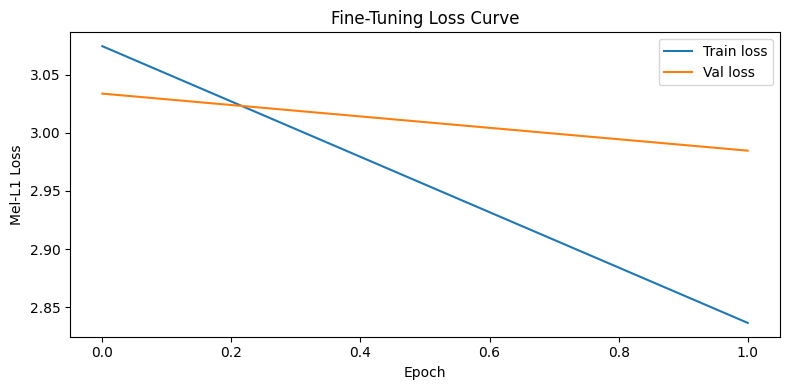

In [10]:
plt.figure(figsize=(8, 4))
plt.plot(history["train"], label="Train loss")
plt.plot(history["val"],   label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Mel-L1 Loss")
plt.title("Fine-Tuning Loss Curve")
plt.legend()
plt.tight_layout()
plt.savefig(f"{Config.OUTPUT_DIR}/loss_curve.png", dpi=150)
plt.show()


In [17]:
# ── Load best checkpoint ───────────────────────────────────────────────────
ckpt = torch.load(Config.BEST_CKPT, map_location=DEVICE)
model.load_state_dict(ckpt["state_dict"])
model.eval()
print(f"Loaded checkpoint from epoch {ckpt['epoch']}  (val={ckpt['val_loss']:.4f})")

SAMPLE_RATE_OUT = model.config.sampling_rate


def generate_audio(text: str, output_path: str):
    """Generate speech from Bangla text using the fine-tuned model."""
    text = pre.normalize(text)
    if not text:
        raise ValueError("Empty text after normalization.")

    inputs = tokenizer(text, return_tensors="pt").to(DEVICE)

    with torch.no_grad():
        output = model(**inputs)
        wav = output.waveform

    audio = wav.squeeze().cpu().numpy()

    # Peak-normalise to prevent clipping
    peak = np.abs(audio).max()
    if peak > 0:
        audio = audio / peak * 0.95

    sf.write(output_path, audio, SAMPLE_RATE_OUT)
    return audio


# ── Evaluate on held-out samples ──────────────────────────────────────────────
from pesq import pesq as pesq_fn

results = []

for i in range(min(Config.NUM_EVAL_SAMPLES, len(val_recs))):
    file_id, text = val_recs[i]
    out_path = f"{Config.OUTPUT_DIR}/eval_{i}.wav"
    ref_path = os.path.join(Config.WAV_DIR, f"{file_id}.wav")

    try:
        gen_audio = generate_audio(text, out_path)
        ref_audio = pre.load_audio(ref_path)

        mel_gen = pre.extract_mel(gen_audio)
        mel_ref = pre.extract_mel(ref_audio)
        t = min(mel_gen.shape[1], mel_ref.shape[1])
        mcd = np.mean((mel_gen[:, :t] - mel_ref[:, :t]) ** 2)

        try:
            # Align lengths for PESQ
            min_len   = min(len(ref_audio), len(gen_audio))
            pesq_score = pesq_fn(16000, ref_audio[:min_len], gen_audio[:min_len], 'wb')
        except Exception:
            pesq_score = None

        results.append({"id": i, "text": text, "MCD": mcd, "PESQ": pesq_score})

        print(f"\n[Sample {i}] {text}")
        display(Audio(out_path))

    except Exception as e:
        print(f"[Sample {i}] Error: {e}")

df_results = pd.DataFrame(results)
print("\n", df_results.to_string(index=False))
df_results.to_csv(f"{Config.OUTPUT_DIR}/eval_results.csv", index=False)


Loaded checkpoint from epoch 2  (val=2.9846)

[Sample 0] শিল্পাঞ্চলে ঢোকার মুখে স্ন্যাক্সবারে খাবার কিনছিলেন বহুজাতিক তথ্যপ্রযুক্তি সংস্থার কর্মী শুভময় বন্দ্যোপাধ্যায়



[Sample 1] অনুশাসনের পাশাপাশি বেতনবৃদ্ধি ঘটিয়ে মাওবাদী অধ্যুষিত এলাকায় পুলিশকর্মীদের পাঠাতে চাইছে ঝাড়খণ্ড সরকার



[Sample 2] সংসদে তাঁর মন্ত্রকের অধীনস্থ রাষ্ট্রায়ত্ত সংস্থাগুলির আর্থিক দায় মেটানোর প্রতিশ্রুতি দিয়েছিলেন সন্তোষমোহন



[Sample 3] শৃঙ্খলাভঙ্গের অভিযোগে ডগলাস ডি সিলভার দুই মাসের বেতন কেটে নেওয়ার সিদ্ধান্ত নিল ইস্টবেঙ্গল



[Sample 4] তন্ত্রের দেবী রূপে কালিকার আরাধনাতেও তথাকথিত নিম্নবর্গীয়দের অংশগ্রহণ বাধ্যতামূলক হইয়া পড়িয়াছিল



  id                                                                                                          text        MCD     PESQ
  0 শিল্পাঞ্চলে ঢোকার মুখে স্ন্যাক্সবারে খাবার কিনছিলেন বহুজাতিক তথ্যপ্রযুক্তি সংস্থার কর্মী শুভময় বন্দ্যোপাধ্যায় 538.951111 1.033990
  1          অনুশাসনের পাশাপাশি বেতনবৃদ্ধি ঘটিয়ে মাওবাদী অধ্যুষিত এলাকায় পুলিশকর্মীদের পাঠাতে চাইছে ঝাড়খণ্ড সরকার 490.624725 1.038946
  2     সংসদে তাঁর মন্ত্রকের অধীনস্থ রাষ্ট্রায়ত্ত সংস্থাগুলির আর্থিক দায় মেটানোর প্রতিশ্রুতি দিয়েছিলেন সন্তোষমোহন 400.162781 1.030457
  3                     শৃঙ্খলাভঙ্গের অভিযোগে ডগলাস ডি সিলভার দুই মাসের বেতন কেটে নেওয়ার সিদ্ধান্ত নিল ইস্টবেঙ্গল 535.960327 1.025750
  4                তন্ত্রের দেবী রূপে কালিকার আরাধনাতেও তথাকথিত নিম্নবর্গীয়দের অংশগ্রহণ বাধ্যতামূলক হইয়া পড়িয়াছিল 409.523682 1.028247


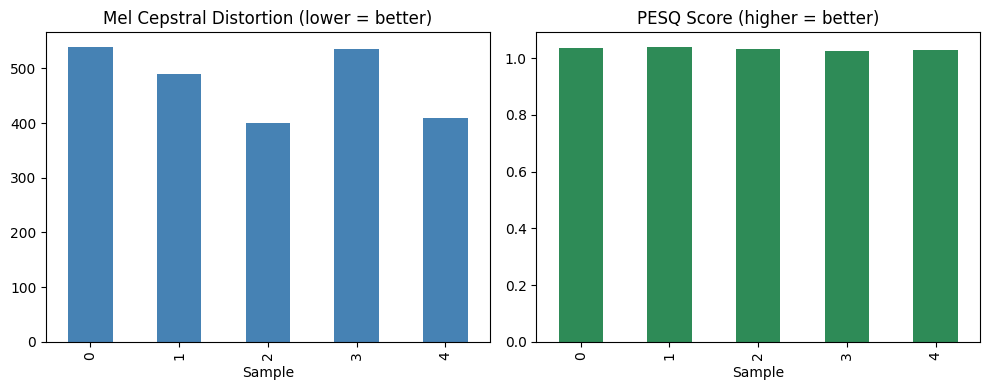

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

if "MCD" in df_results.columns:
    df_results["MCD"].plot(kind="bar", ax=axes[0], color="steelblue")
    axes[0].set_title("Mel Cepstral Distortion (lower = better)")
    axes[0].set_xlabel("Sample")

if "PESQ" in df_results.columns and df_results["PESQ"].notna().any():
    df_results["PESQ"].plot(kind="bar", ax=axes[1], color="seagreen")
    axes[1].set_title("PESQ Score (higher = better)")
    axes[1].set_xlabel("Sample")

plt.tight_layout()
plt.savefig(f"{Config.OUTPUT_DIR}/eval_metrics.png", dpi=150)
plt.show()


In [19]:
save_dir = "/kaggle/working/fine_tuned_model"
model.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)
print(f"Fine-tuned model saved to {save_dir}")
print("To reload: VitsModel.from_pretrained('/kaggle/working/fine_tuned_model')")


Fine-tuned model saved to /kaggle/working/fine_tuned_model
To reload: VitsModel.from_pretrained('/kaggle/working/fine_tuned_model')
